# Session Clustering via Hierarchical Agglomerative Clustering

Use the pre-computed normalized Levenshtein distance matrix (unique-sequence level)
to cluster sessions with **Agglomerative Clustering (average linkage)**.
Draw a dendrogram, cut at k=9 and at the "natural" k (largest merge-distance gap),
visualize with t-SNE, and print representative examples.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score

import warnings

warnings.filterwarnings("ignore")

## 1. Load Pre-computed Data

In [2]:
DATA_DIR = Path("../data/clusters/distances")
MIN_MESSAGES = 5  # exclude sessions with <= 4 messages

# Distance matrix over unique sequences (n_unique x n_unique)
dist_matrix_unique = np.load(DATA_DIR / "distance_matrix.npy")
print(f"Unique distance matrix shape: {dist_matrix_unique.shape}")

# sha -> unique sequence index mapping
with open(DATA_DIR / "sha_to_sequence_idx.json") as f:
    sha_to_idx = json.load(f)

# Metadata
with open(DATA_DIR / "metadata.json") as f:
    metadata = json.load(f)

print(f"Total sessions: {metadata['n_sessions']}")
print(f"Unique sequences: {metadata['n_unique_sequences']}")
print(f"Parameters: {metadata['parameters']}")

# Count messages per session from classification data
clf_df = pd.read_csv(
    "../data/classifications/classifications_for_analysis.csv",
    usecols=["sha", "index_in_chat"],
)
msg_counts = clf_df.groupby("sha")["index_in_chat"].nunique()

# Filter: keep sessions with >= MIN_MESSAGES messages
valid_shas = set(msg_counts[msg_counts >= MIN_MESSAGES].index)
shas = sorted(sha for sha in sha_to_idx if sha in valid_shas)
n_filtered = len(sha_to_idx) - len(shas)
print(f"\nFiltered out {n_filtered} sessions with < {MIN_MESSAGES} messages")
print(f"Remaining sessions: {len(shas)}")

# Expand to session-level distance matrix
idx_array = np.array([sha_to_idx[sha] for sha in shas])
dist_matrix = dist_matrix_unique[np.ix_(idx_array, idx_array)]
print(f"Session-level distance matrix shape: {dist_matrix.shape}")

Unique distance matrix shape: (6787, 6787)
Total sessions: 11579
Unique sequences: 6787
Parameters: {'indel_weight': 1.0, 'same_parent_weight': 0.5, 'cross_parent_weight': 1.0, 'normalize': True}

Filtered out 7523 sessions with < 5 messages
Remaining sessions: 4056
Session-level distance matrix shape: (4056, 4056)


## 2. Hierarchical Agglomerative Clustering (Average Linkage)

In [3]:
# Convert square distance matrix to condensed form for scipy
condensed_dist = squareform(dist_matrix, checks=False)

# Average-linkage agglomerative clustering
Z = linkage(condensed_dist, method="average")
print(f"Linkage matrix shape: {Z.shape}")
print(f"Min merge distance: {Z[:, 2].min():.4f}")
print(f"Max merge distance: {Z[:, 2].max():.4f}")

Linkage matrix shape: (4055, 4)
Min merge distance: 0.0000
Max merge distance: 0.9313


## 3. Dendrogram

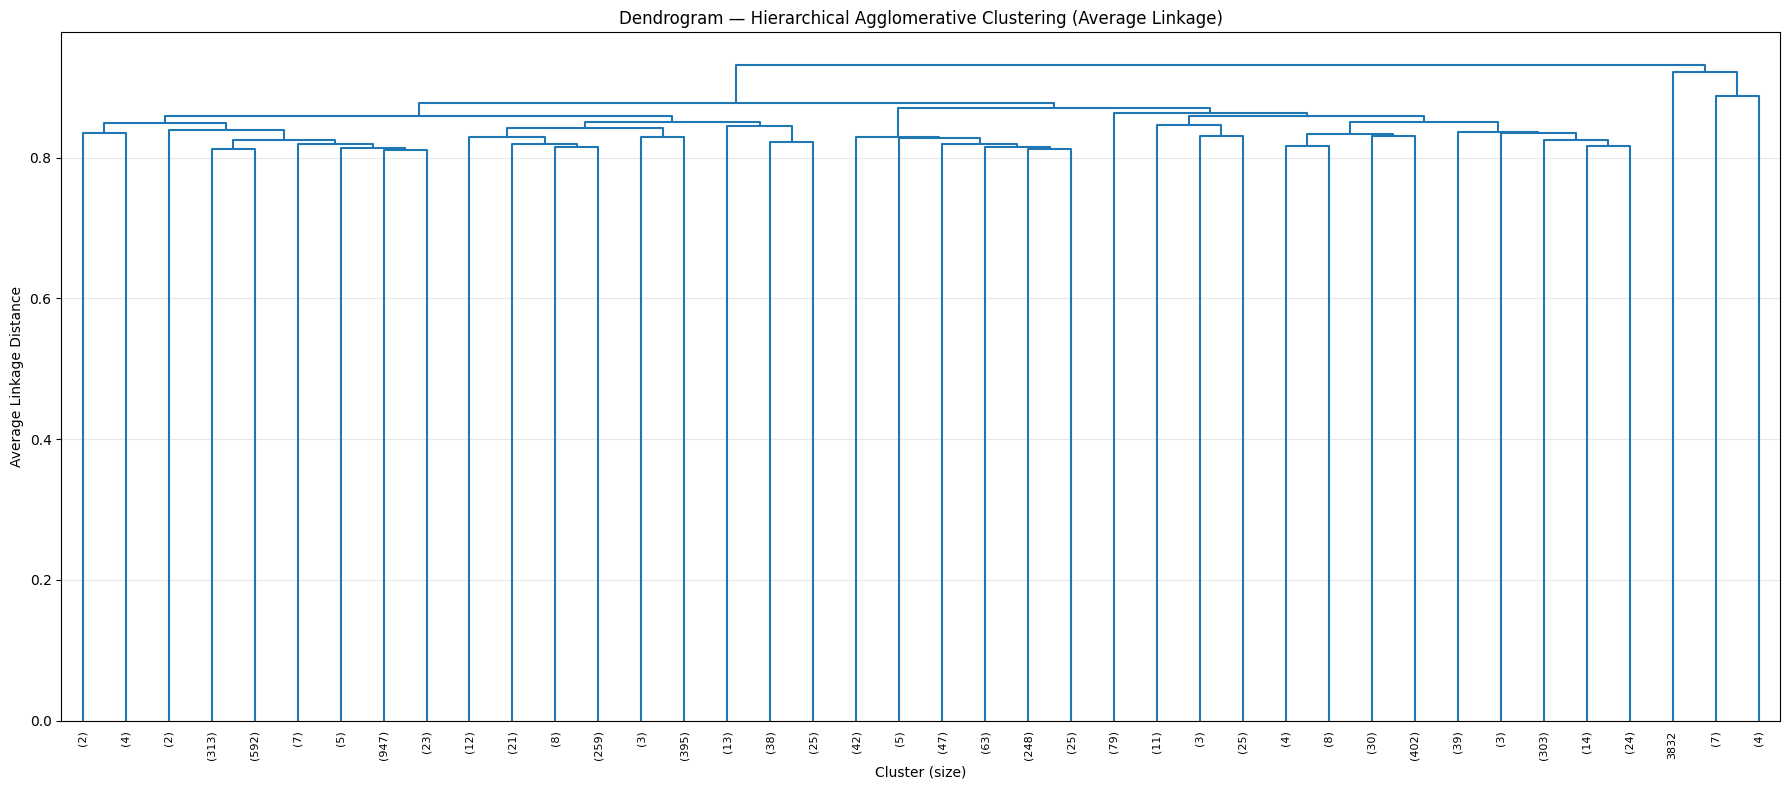

In [4]:
fig, ax = plt.subplots(figsize=(18, 8))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=40,  # show last 40 merges
    leaf_rotation=90,
    leaf_font_size=8,
    ax=ax,
    color_threshold=0,
)

ax.set_xlabel("Cluster (size)")
ax.set_ylabel("Average Linkage Distance")
ax.set_title("Dendrogram — Hierarchical Agglomerative Clustering (Average Linkage)")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 4. Determine Natural k (Largest Gap in Merge Distances)

In [5]:
# Merge distances are in Z[:, 2], ordered from smallest to largest
merge_distances = Z[:, 2]

# Look at the last N-1 merges (going from n clusters down to 1)
# The gap between consecutive merge distances tells us where a natural cut is
# We search among reasonable k values (2..20)
MAX_K_SEARCH = 20
n = len(shas)

# The last (n-1) merges correspond to going from n clusters to 1
# merge_distances[-(k-1)] is the distance at which we go from k clusters to k-1
# The gap for cutting at k clusters = merge_distances[-(k-1)] - merge_distances[-(k)]

gaps = []
for k in range(2, MAX_K_SEARCH + 1):
    # Distance when merging from k to k-1 clusters
    d_merge = merge_distances[-(k - 1)]
    # Distance when merging from k+1 to k clusters
    d_prev = merge_distances[-k] if k < n else 0
    gap = d_merge - d_prev
    gaps.append({"k": k, "merge_dist": d_merge, "gap": gap})

df_gaps = pd.DataFrame(gaps)
natural_k = int(df_gaps.loc[df_gaps["gap"].idxmax(), "k"])

print("Merge distance gaps (top 10):")
print(df_gaps.sort_values("gap", ascending=False).head(10).to_string(index=False))
print(f"\nNatural k (largest gap): {natural_k}")

Merge distance gaps (top 10):
 k  merge_dist      gap
 3    0.920820 0.034040
 2    0.931315 0.010495
 4    0.886780 0.009842
 9    0.858870 0.008436
 6    0.870676 0.007221
 5    0.876938 0.006262
 7    0.863455 0.004392
14    0.845241 0.003409
15    0.841832 0.003031
12    0.848672 0.002198

Natural k (largest gap): 3


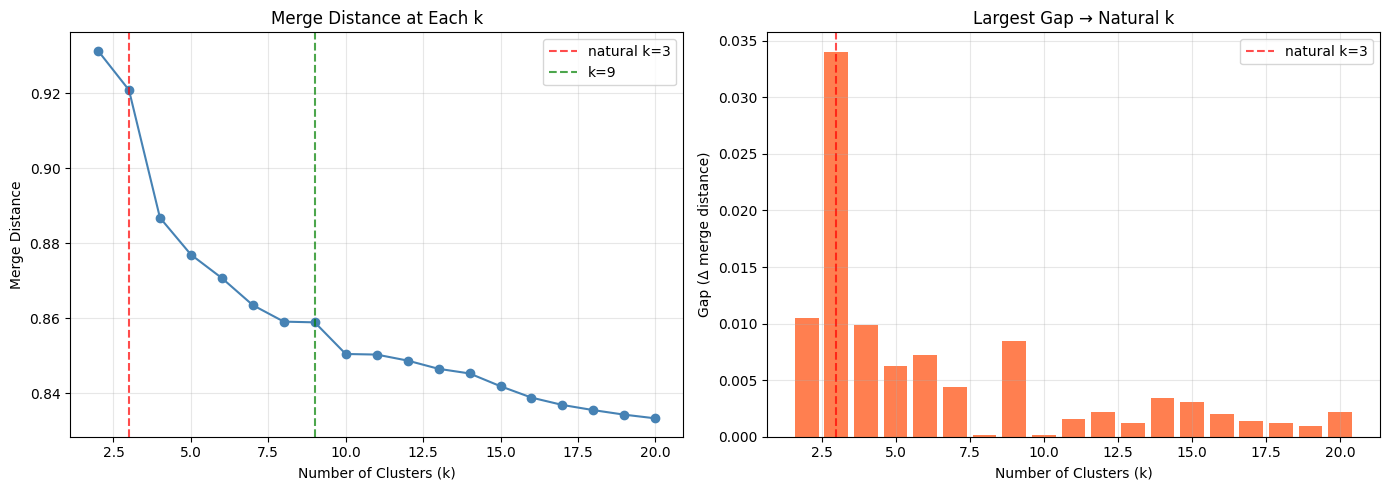

In [6]:
# Visualize gaps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Merge distance at each k
axes[0].plot(df_gaps["k"], df_gaps["merge_dist"], "o-", color="steelblue")
axes[0].axvline(
    natural_k, color="red", linestyle="--", alpha=0.7, label=f"natural k={natural_k}"
)
axes[0].axvline(9, color="green", linestyle="--", alpha=0.7, label="k=9")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Merge Distance")
axes[0].set_title("Merge Distance at Each k")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gap plot
axes[1].bar(df_gaps["k"], df_gaps["gap"], color="coral")
axes[1].axvline(
    natural_k, color="red", linestyle="--", alpha=0.7, label=f"natural k={natural_k}"
)
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Gap (Δ merge distance)")
axes[1].set_title("Largest Gap → Natural k")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Cut Dendrogram at k=9 and Natural k

In [7]:
# Cut at k=9
labels_k9 = fcluster(Z, t=9, criterion="maxclust") - 1  # 0-indexed
sil_k9 = silhouette_score(dist_matrix, labels_k9, metric="precomputed")
print(f"k=9:  silhouette={sil_k9:.4f}")
print("Cluster sizes:")
print(pd.Series(labels_k9).value_counts().sort_index().to_string())

print()

# Cut at natural k
labels_natural = fcluster(Z, t=natural_k, criterion="maxclust") - 1  # 0-indexed
sil_natural = silhouette_score(dist_matrix, labels_natural, metric="precomputed")
print(f"k={natural_k} (natural):  silhouette={sil_natural:.4f}")
print("Cluster sizes:")
print(pd.Series(labels_natural).value_counts().sort_index().to_string())

k=9:  silhouette=0.0351
Cluster sizes:
0    1895
1     774
2     430
3      79
4      39
5     827
6       7
7       4
8       1

k=3 (natural):  silhouette=0.0640
Cluster sizes:
0    4044
1      11
2       1


## 6. Dendrogram with Cut Lines

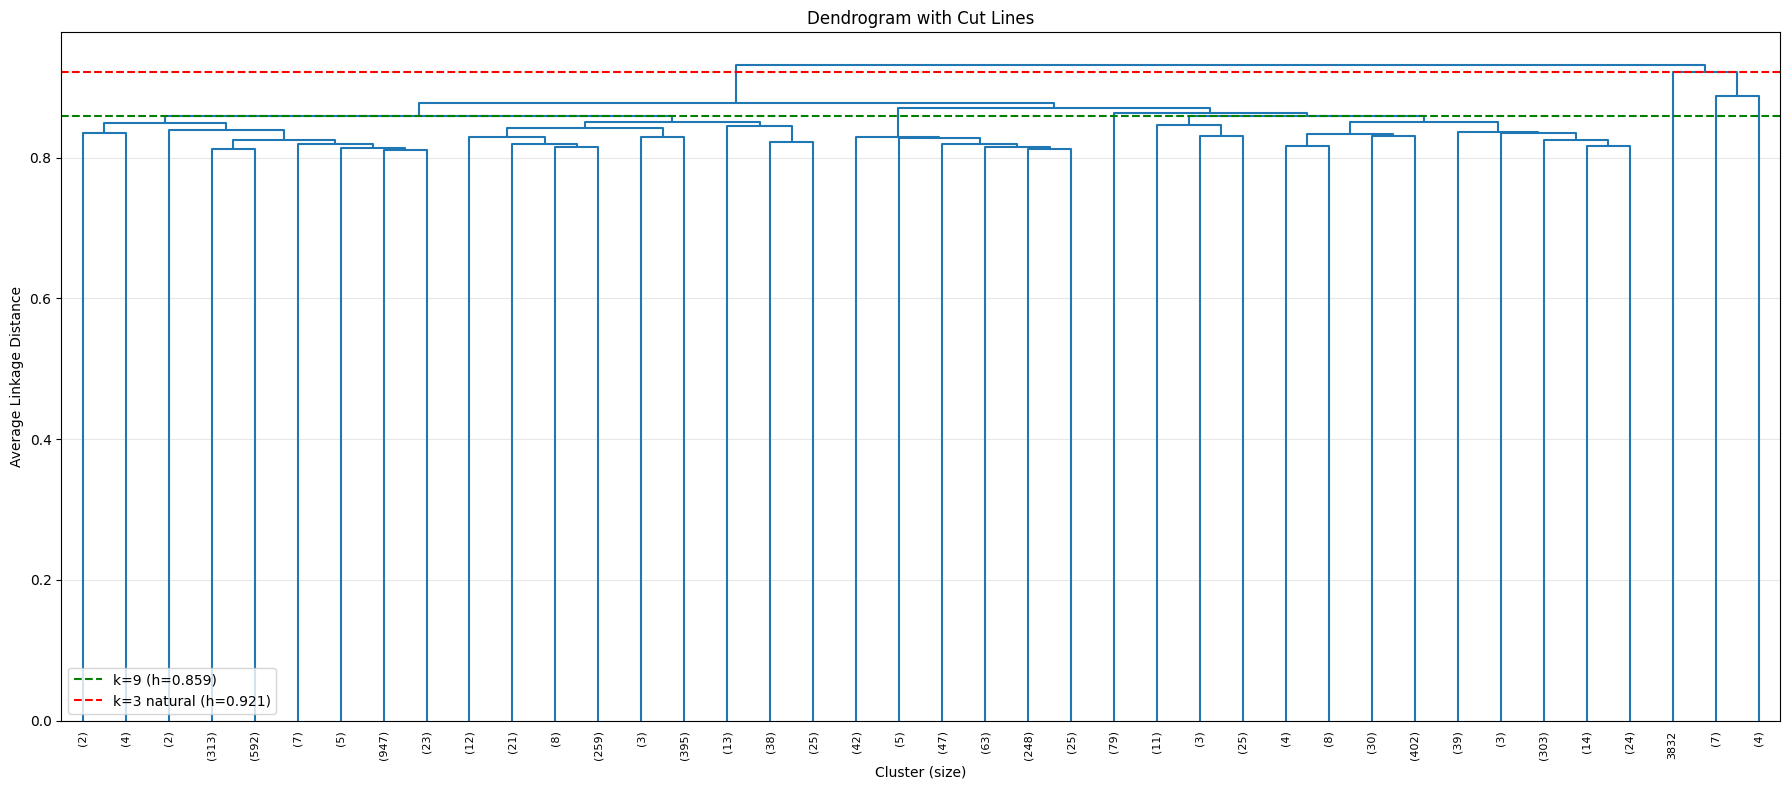

In [8]:
# Cut heights: the merge distance at which we go from k to k-1 clusters
cut_height_k9 = merge_distances[-(9 - 1)]
cut_height_natural = merge_distances[-(natural_k - 1)]

fig, ax = plt.subplots(figsize=(18, 8))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=40,
    leaf_rotation=90,
    leaf_font_size=8,
    ax=ax,
    color_threshold=0,
)

ax.axhline(
    cut_height_k9,
    color="green",
    linestyle="--",
    linewidth=1.5,
    label=f"k=9 (h={cut_height_k9:.3f})",
)
if natural_k != 9:
    ax.axhline(
        cut_height_natural,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label=f"k={natural_k} natural (h={cut_height_natural:.3f})",
    )

ax.set_xlabel("Cluster (size)")
ax.set_ylabel("Average Linkage Distance")
ax.set_title("Dendrogram with Cut Lines")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 7. t-SNE Visualization

Project the precomputed distance matrix into 2D via t-SNE.

In [9]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    metric="precomputed",
    init="random",
    random_state=42,
    perplexity=30,
    max_iter=1000,
)
coords_2d = tsne.fit_transform(dist_matrix)
print(f"t-SNE embedding shape: {coords_2d.shape}")

t-SNE embedding shape: (4056, 2)


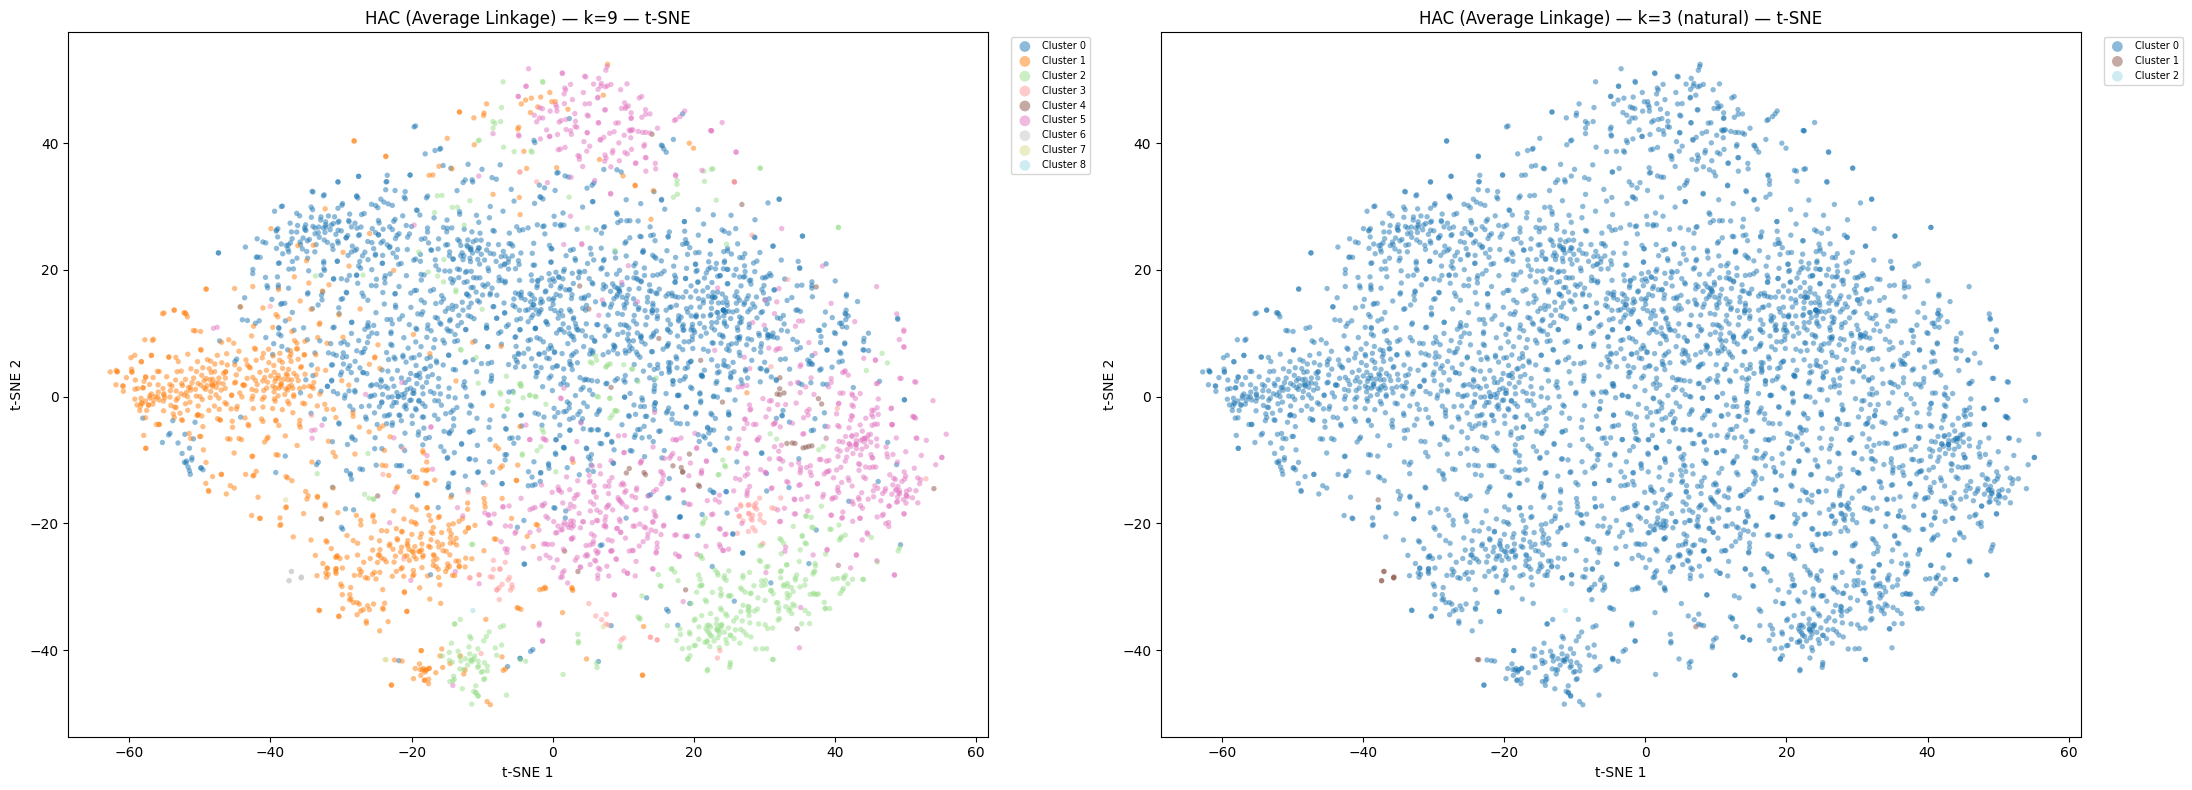

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

for ax, labels, k, title_suffix in [
    (axes[0], labels_k9, 9, "k=9"),
    (axes[1], labels_natural, natural_k, f"k={natural_k} (natural)"),
]:
    cmap = plt.cm.get_cmap("tab20", k)
    for c in range(k):
        mask = labels == c
        ax.scatter(
            coords_2d[mask, 0],
            coords_2d[mask, 1],
            c=[cmap(c)],
            label=f"Cluster {c}",
            alpha=0.5,
            s=15,
            edgecolors="none",
        )
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.set_title(f"HAC (Average Linkage) — {title_suffix} — t-SNE")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, markerscale=2)

plt.tight_layout()
plt.show()

## 8. Representative Examples per Cluster

For each cluster, show the 3 sessions closest to the cluster centroid
(the session with the smallest average distance to all other members)
and print their sub-category label sequences.

In [11]:
# Load classification data for sequences
clf_full = pd.read_csv(
    "../data/classifications/classifications_for_analysis.csv",
    usecols=["sha", "index_in_chat", "main_category", "sub_category"],
)

# Build label-set sequences per sha (same logic as compute_distances.py)
label_sets = (
    clf_full.groupby(["sha", "index_in_chat"])
    .apply(
        lambda g: [s for s in g["sub_category"]],
        include_groups=False,
    )
    .reset_index(name="labels")
)

sha_sequences = (
    label_sets.sort_values(["sha", "index_in_chat"])
    .groupby("sha")["labels"]
    .apply(list)
    .to_dict()
)

print(f"Loaded sequences for {len(sha_sequences)} sessions")

Loaded sequences for 11579 sessions


In [12]:
def print_representative_examples(labels, k, title):
    """Print top-3 representative sessions per cluster (closest to cluster centroid)."""
    N_EXAMPLES = 3
    print(f"\n{'#'*80}")
    print(f"# {title}")
    print(f"{'#'*80}")

    for c in range(k):
        cluster_mask = np.where(labels == c)[0]
        cluster_size = len(cluster_mask)

        # Centroid: the session with smallest mean distance to other cluster members
        sub_dist = dist_matrix[np.ix_(cluster_mask, cluster_mask)]
        mean_dists = sub_dist.mean(axis=1)
        centroid_local = np.argmin(mean_dists)
        centroid_global = cluster_mask[centroid_local]

        # Top-N closest to centroid
        dists_to_centroid = sub_dist[centroid_local]
        nearest = np.argsort(dists_to_centroid)[:N_EXAMPLES]

        print(f"\n{'='*80}")
        print(
            f"CLUSTER {c}  |  {cluster_size} sessions  |  "
            f"centroid: {shas[centroid_global][:12]}..."
        )
        print(f"{'='*80}")

        for rank, local_idx in enumerate(nearest):
            global_idx = cluster_mask[local_idx]
            dist = dists_to_centroid[local_idx]
            sha = shas[global_idx]

            seq = sha_sequences.get(sha, [])

            print(f"\n  Example {rank+1}  (dist to centroid: {dist:.4f})")
            print(f"  SHA: {sha}")
            print(f"  Sequence length: {len(seq)}")
            for pos, lbls in enumerate(seq):
                if len(lbls) == 1:
                    print(f"    [{pos}] {lbls[0]}")
                else:
                    print(f"    [{pos}] {' + '.join(lbls)}")

In [13]:
print_representative_examples(labels_k9, 9, "HAC Average Linkage — k=9")


################################################################################
# HAC Average Linkage — k=9
################################################################################

CLUSTER 0  |  1895 sessions  |  centroid: edc4a4ce92e2...

  Example 1  (dist to centroid: 0.0000)
  SHA: edc4a4ce92e2f49d2d1ab3b394070cd3fc67cdce
  Sequence length: 8
    [0] 1.2 Iterative Modification
    [1] 1.2 Iterative Modification
    [2] 2.2 Symptom Description
    [3] 1.2 Iterative Modification
    [4] 1.2 Iterative Modification
    [5] 2.2 Symptom Description
    [6] 2.2 Symptom Description
    [7] 1.2 Iterative Modification + 2.2 Symptom Description

  Example 2  (dist to centroid: 0.3125)
  SHA: 42f7047cf464dc0ca48595ee32efc754fd1e610d
  Sequence length: 8
    [0] 1.2 Iterative Modification
    [1] 1.2 Iterative Modification
    [2] 2.2 Symptom Description
    [3] 2.2 Symptom Description + 2.1 Log Paste
    [4] 2.2 Symptom Description + 1.2 Iterative Modification
    [5] 2.2 Symptom De

In [14]:
print_representative_examples(
    labels_natural, natural_k, f"HAC Average Linkage — k={natural_k} (natural)"
)


################################################################################
# HAC Average Linkage — k=3 (natural)
################################################################################

CLUSTER 0  |  4044 sessions  |  centroid: edc4a4ce92e2...

  Example 1  (dist to centroid: 0.0000)
  SHA: edc4a4ce92e2f49d2d1ab3b394070cd3fc67cdce
  Sequence length: 8
    [0] 1.2 Iterative Modification
    [1] 1.2 Iterative Modification
    [2] 2.2 Symptom Description
    [3] 1.2 Iterative Modification
    [4] 1.2 Iterative Modification
    [5] 2.2 Symptom Description
    [6] 2.2 Symptom Description
    [7] 1.2 Iterative Modification + 2.2 Symptom Description

  Example 2  (dist to centroid: 0.3125)
  SHA: dea093866aa3765b4a7bde4e727dece8a8a1d24c
  Sequence length: 6
    [0] 6.1 Documentation + 1.2 Iterative Modification
    [1] 1.2 Iterative Modification
    [2] 2.2 Symptom Description
    [3] 1.2 Iterative Modification
    [4] 1.2 Iterative Modification
    [5] 2.2 Symptom Description